In [253]:
import pandas as pd

df = pd.read_excel("../dataset/Telco_customer_churn.xlsx")

In [254]:
# Menampilkan data
print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [255]:
# Info dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [256]:
# Statistik
print(df.describe())

        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000000     5.000000  2003.000000  
25%          35.500000     0.00

In [257]:
# Missing value
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [258]:
# Duplicate
print("Duplicate :", df.duplicated().sum())

Duplicate : 0


In [259]:
# Check imbalance
print(df["Churn Label"].value_counts())
print(df["Churn Label"].value_counts(normalize=True) * 100)

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


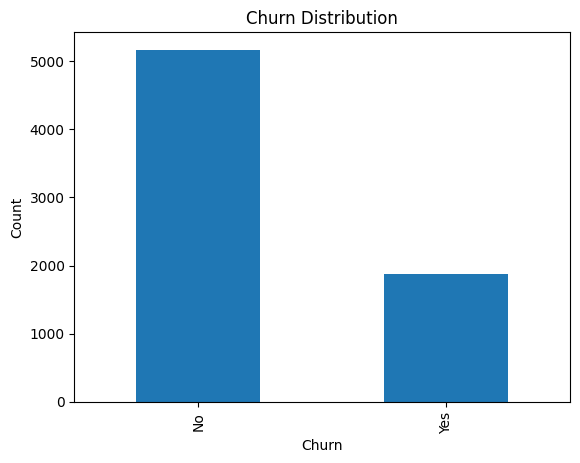

In [260]:
import matplotlib.pyplot as plt

df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [261]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Reason",
    "Churn Value",
    "Churn Score"
]

df = df.drop(columns=drop_columns)

print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Phone Service  \
0    Male             No      No         No              2           Yes   
1  Female             No      No        Yes              2           Yes   
2  Female             No      No        Yes              8           Yes   
3  Female             No     Yes        Yes             28           Yes   
4    Male             No      No        Yes             49           Yes   

  Multiple Lines Internet Service Online Security Online Backup  ...  \
0             No              DSL             Yes           Yes  ...   
1             No      Fiber optic              No            No  ...   
2            Yes      Fiber optic              No            No  ...   
3            Yes      Fiber optic              No            No  ...   
4            Yes      Fiber optic              No           Yes  ...   

  Tech Support Streaming TV Streaming Movies        Contract  \
0           No           No               No  

In [262]:
print(df.dtypes)

Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
CLTV                   int64
dtype: object


In [263]:
# Convert Total Charges menjadi numeric
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

# Cek missing value setelah convert
print(df["Total Charges"].isnull().sum())

# Mengisi Missing Value

df["Total Charges"] = df["Total Charges"].fillna(
    df["Total Charges"].median()
)

11


In [264]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#mengambil semua kolom object/string
categorical_columns = df.select_dtypes(include=["object"]).columns

# Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
    
print(df.head())

   Gender  Senior Citizen  Partner  Dependents  Tenure Months  Phone Service  \
0       1               0        0           0              2              1   
1       0               0        0           1              2              1   
2       0               0        0           1              8              1   
3       0               0        1           1             28              1   
4       1               0        0           1             49              1   

   Multiple Lines  Internet Service  Online Security  Online Backup  ...  \
0               0                 0                2              2  ...   
1               0                 1                0              0  ...   
2               2                 1                0              0  ...   
3               2                 1                0              0  ...   
4               2                 1                0              2  ...   

   Tech Support  Streaming TV  Streaming Movies  Contract  Pap

C:\Users\muham\AppData\Local\Temp\ipykernel_18420\1074419216.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [265]:
# Checking Numeric
print(df.dtypes)

Gender                 int64
Senior Citizen         int64
Partner                int64
Dependents             int64
Tenure Months          int64
Phone Service          int64
Multiple Lines         int64
Internet Service       int64
Online Security        int64
Online Backup          int64
Device Protection      int64
Tech Support           int64
Streaming TV           int64
Streaming Movies       int64
Contract               int64
Paperless Billing      int64
Payment Method         int64
Monthly Charges      float64
Total Charges        float64
Churn Label            int64
CLTV                   int64
dtype: object


In [266]:
# Features dan Target
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

print(" X Shape : ", X.shape)
print(" y Shape : ", y.shape)

 X Shape :  (7043, 20)
 y Shape :  (7043,)


In [267]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test : ", X_test.shape)
print("y_train : ", y_train.shape)
print("y_test : ", y_test.shape)

X_train : (5634, 20)
X_test :  (1409, 20)
y_train :  (5634,)
y_test :  (1409,)


In [268]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Buat Model
lr = LogisticRegression(max_iter=1000)

# Training
lr.fit(X_train, y_train)

# Prediction
y_pred_lr = lr.predict(X_test)

# Evaluation
print(" ============ Logistic Regression Result ============= ")

print("Accuracy : ", accuracy_score(y_test, y_pred_lr))
print("Precision : ", precision_score(y_test, y_pred_lr))
print("Recall Score : ", recall_score(y_test, y_pred_lr))
print("F1 Score : ", f1_score(y_test, y_pred_lr))

print("\n Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred_lr))


 ============ Logistic Regression Result ============= 
Accuracy :  0.8019872249822569
Precision :  0.6784660766961652
Recall Score :  0.575
F1 Score :  0.6224627875507442

 Confusion Matrix : 
[[900 109]
 [170 230]]


c:\Users\muham\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [269]:
from sklearn.ensemble import RandomForestClassifier

# Model
rf = RandomForestClassifier()

# Training
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Evaluation
print(" ============= Random Forest Classifier ============= ")

print("Accuracy : ", accuracy_score(y_test, y_pred_rf))
print("Precision : ", precision_score(y_test, y_pred_rf))
print("Recall Score : ", recall_score(y_test, y_pred_rf))
print("F1 Score : ", f1_score(y_test, y_pred_rf))

print("\n Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred_rf))



 ============= Random Forest Classifier ============= 
Accuracy :  0.7899219304471257
Precision :  0.6635220125786163
Recall Score :  0.5275
F1 Score :  0.5877437325905293

 Confusion Matrix : 
[[902 107]
 [189 211]]


In [270]:
from xgboost import XGBClassifier

# Model 
xgb = XGBClassifier(
    randomstate = 42,
    eval_metric = "logloss"
)

# Training
xgb.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb.predict(X_test)

# Evaluation
print("============ XGBoost Result ============")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall Score :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\n Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred_xgb))

============ XGBoost Result ============
Accuracy : 0.7984386089425124
Precision : 0.676829268292683
Recall Score : 0.555
F1 Score : 0.6098901098901099

 Confusion Matrix : 
[[903 106]
 [178 222]]


In [271]:
import matplotlib.pyplot as plt
import pandas as pd

# Data Comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf) ,
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
})

print(comparison)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.801987  0.622463
1        Random Forest  0.789922  0.587744
2              XGBoost  0.798439  0.609890


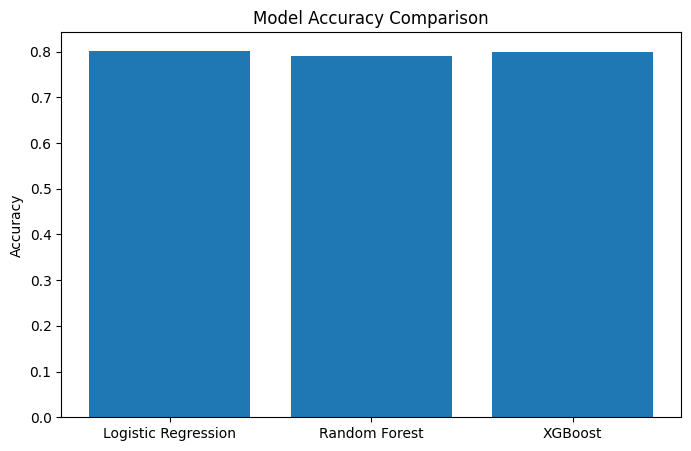

In [272]:
# Visualization

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

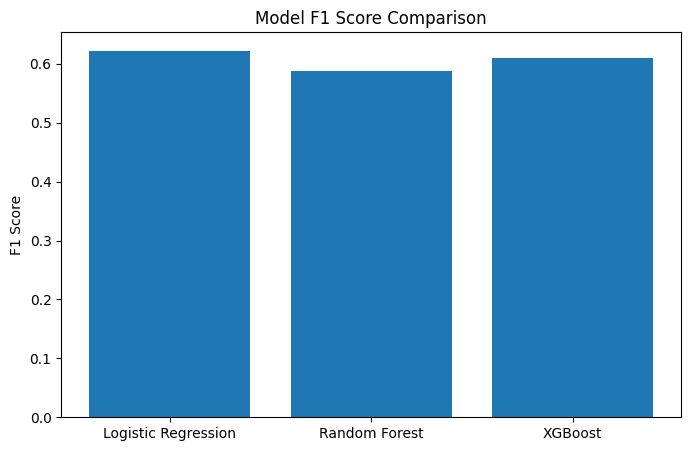

In [273]:
# Visualization F1-Score

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")

plt.show()

In [274]:
import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(lr, file)
    
print("Best model berhasil disimpan sebagai best_model.pkl")

Best model berhasil disimpan sebagai best_model.pkl
